In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, pairwise_distances
import hdbscan
from sklearn.manifold import TSNE
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score, normalized_mutual_info_score
import os

DATA LOADING

In [2]:
# Leggi df_factors
df_factors = pd.read_csv("PDAC_DATA_MOFA_DATA/df_factors.csv", index_col=0)
print("df_factors caricato:")
print(df_factors.head())

# Leggi le matrici dei pesi per ogni vista
weights_per_view={
    "circRNA": None,
    "miRNA": None,
    "mRNA": None,
    "phosphoproteome": None,
    "proteome": None,
    "SCNA": None
}
for view_name in weights_per_view.keys():
    weights_per_view[view_name] = pd.read_csv(
        f"PDAC_DATA_MOFA_DATA/weights_{view_name}.csv",
        index_col=0
    )

clinical_df= pd.read_csv("PDAC_DATA_PREPROCESSED/numerical_clinical.csv",index_col=0)

true_labels_vs = clinical_df["vital_status"]

true_labels_ts = clinical_df["tumor_stage_numerical"]



df_factors caricato:
            Factor1   Factor2   Factor3   Factor4   Factor5   Factor6  \
case_id                                                                 
C3L-00017  3.772759 -0.024180 -0.039678  1.375110 -0.551716 -0.176812   
C3L-00102  1.362362 -0.283709  0.847602  3.748061 -1.124642  0.037608   
C3L-00189  2.768533 -1.336807  0.614068 -0.476359  1.154339  0.115143   
C3L-00277  1.526149  1.867423  1.530237  1.292304 -0.362401 -0.072971   
C3L-00401  3.035923  0.111856  0.122542  0.457961 -0.341562 -0.069621   

            Factor7   Factor8   Factor9  Factor10  Factor11  Factor12  \
case_id                                                                 
C3L-00017  0.165779 -0.112902  1.244698 -0.197673 -0.659694  0.129649   
C3L-00102  0.609494 -0.072042 -0.812959 -0.028058  0.364193  0.017682   
C3L-00189  0.248770 -0.084077 -0.418311 -0.135630 -0.080273 -0.006149   
C3L-00277 -0.124941 -0.226568  0.509663 -0.446523 -0.404787 -0.060446   
C3L-00401  0.115786 -0.087630

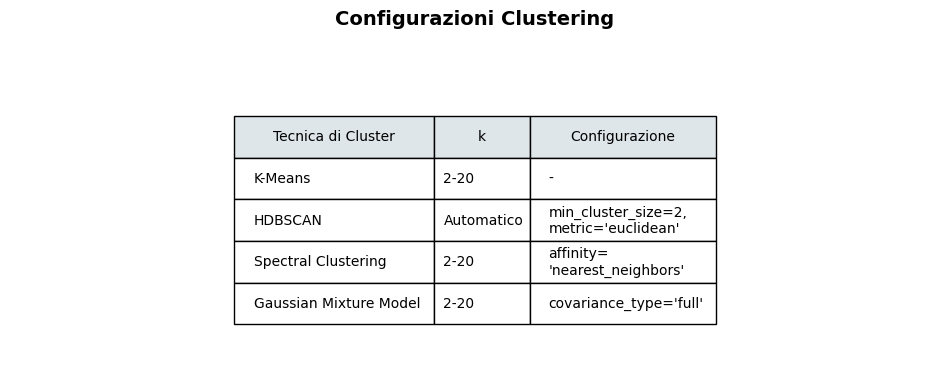

In [21]:
# Dati della tabella
# Usiamo \n o textwrap per mandare a capo le stringhe lunghe
data = [
    ["K-Means", "2-20", "-"],
    ["HDBSCAN", "Automatico", "min_cluster_size=2,\nmetric='euclidean'"],
    ["Spectral Clustering", "2-20", "affinity=\n'nearest_neighbors'"],
    ["Gaussian Mixture Model", "2-20", "covariance_type='full'"]
]
columns = ("Tecnica di Cluster", "k", "Configurazione")

fig, ax = plt.subplots(figsize=(12, 4)) # Allarghiamo un po' la figura
ax.axis('tight')
ax.axis('off')

# Creazione della tabella
tbl = ax.table(cellText=data, 
               colLabels=columns, 
               loc='center', 
               cellLoc='left',
               colColours=["#dfe6e9"] * 3)

# --- TRUCCHI PER IL TESTO FUORI CELLA ---
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)

# 1. auto_set_column_width: adatta la larghezza delle colonne al contenuto
tbl.auto_set_column_width(col=list(range(len(columns))))

# 2. scale: aumenta l'altezza (secondo parametro) per evitare che il testo tocchi i bordi
tbl.scale(1, 2.5) 

plt.title("Configurazioni Clustering", pad=30, weight='bold', size=14)
plt.show()

CLUSTERING

In [3]:
X = df_factors


MIN_CLUSTERS = 2
MAX_CLUSTERS = 21   #11

label_mapping_vs={0: "Living", 1: "Deceased"}
label_mapping_ts={1: "Stage I", 2: "Stage II", 3: "Stage III", 4: "Stage IV"}

def calculate_silhouette_score(X, labels):
    return silhouette_score(X, labels)

def calculate_davies_bouldin_score(X, labels):
    return davies_bouldin_score(X, labels)

def calculate_calinski_harabasz_score(X, labels):
    return calinski_harabasz_score(X, labels)

def calculate_adjusted_rand_index(true_labels, predicted_labels):
    return adjusted_rand_score(true_labels, predicted_labels)

def calculate_normalized_mutual_info_index(true_labels, predicted_labels):
    return normalized_mutual_info_score(true_labels, predicted_labels)

In [4]:
# DEFINIZIONE GRAFICI

# --- Funzione 0: T-SNE ---
def plot_tsne(
    X,
    labels=None,
    outlier_label=-1,
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,
    random_state=42,
    figsize=(10, 8),
    title="t-SNE Visualization",
    point_size=50
):
    tsne = TSNE(
        n_components=n_components,
        perplexity=perplexity,
        learning_rate=learning_rate,
        max_iter=max_iter,
        random_state=random_state
    )

    X_tsne = tsne.fit_transform(X)

    plt.figure(figsize=figsize)

    if labels is None:
        plt.scatter(
            X_tsne[:, 0],
            X_tsne[:, 1],
            s=point_size,
            alpha=0.8,
            edgecolor="black",
            linewidth=0.3
        )
    else:
        labels = np.array(labels)
        unique_labels = np.unique(labels)
        cluster_labels = [l for l in unique_labels if l != outlier_label]

        n_clusters = len(cluster_labels)

        # === PALETTE COLORI VIVACI ===
        if n_clusters <= 9:
            base_colors = plt.get_cmap("Set1").colors
            colors = base_colors[:n_clusters]
        else:
            # fallback per molti cluster
            colors = plt.cm.hsv(np.linspace(0, 1, n_clusters))

        color_map = {cls: colors[i] for i, cls in enumerate(cluster_labels)}

        for cls in unique_labels:
            idx = labels == cls

            if cls == outlier_label:
                plt.scatter(
                    X_tsne[idx, 0],
                    X_tsne[idx, 1],
                    c="lightgray",
                    s=point_size,
                    alpha=0.5,
                    label="Outlier"
                )
            else:
                plt.scatter(
                    X_tsne[idx, 0],
                    X_tsne[idx, 1],
                    c=[color_map[cls]],
                    s=point_size,
                    alpha=0.9,
                    label=f"Cluster {cls}",
                    edgecolor="black",
                    linewidth=0.4
                )

        plt.legend(
            title="Cluster label",
            #bbox_to_anchor=(1.05, 1),
            loc="upper right",
            fontsize="x-small",
            frameon=True,
            framealpha=0.7,
            markerscale=1.3
        )

    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# --- Funzione 1: Silhouette Score ---
def plot_silhouette(k_values, sil_scores):
    plt.figure()
    plt.plot(k_values, sil_scores, marker='o', color='blue', linewidth=0.8, markersize=2)
    plt.xlabel("k")
    plt.ylabel("Silhouette Score")
    plt.xlim(left=0)
    plt.ylim(bottom=0)
    plt.title("Silhouette Score vs k")
    plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    plt.show()

# --- Funzione 2: Davies–Bouldin Index ---
def plot_davies_bouldin(k_values, db_scores):
    plt.figure()
    plt.plot(k_values, db_scores, marker='o', color='red')
    plt.xlabel("k")
    plt.ylabel("Davies–Bouldin Index")
    plt.title("Davies–Bouldin Index vs k")
    plt.grid(True)
    plt.show()

# --- Funzione 3: Calinski–Harabasz Index ---
def plot_calinski_harabasz(k_values, ch_scores):
    plt.figure()
    plt.plot(k_values, ch_scores, marker='o', color='green')
    plt.xlabel("k")
    plt.ylabel("Calinski–Harabasz Index")
    plt.title("Calinski–Harabasz Index vs k")
    plt.grid(True)
    plt.show()

# --- Funzione 4: Adjusted Rand Index (ARI) ---
def plot_ari(k_values, ari_scores):
    plt.figure()
    plt.plot(k_values, ari_scores, marker='o', color='purple')
    plt.xlabel("k")
    plt.ylabel("Adjusted Rand Index (ARI)")
    plt.title("ARI vs k")
    plt.grid(True)
    plt.show()

# --- Funzione 5: Normalized Mutual Information (NMI) ---
def plot_nmi(k_values, nmi_scores):
    plt.figure()
    plt.plot(k_values, nmi_scores, marker='o', color='orange')
    plt.xlabel("k")
    plt.ylabel("Normalized Mutual Information (NMI)")
    plt.title("NMI vs k")
    plt.grid(True)
    plt.show()

# --- Funzione 6: (Bayesian Information Criterion) BIC---
def plot_bic(k_values, bic_scores):
    plt.figure()
    plt.plot(k_values, bic_scores, marker='o', color='blue', linewidth=0.8, markersize=2)
    plt.xlabel("k")
    plt.ylabel("(Bayesian Information Criterion) BIC")
    plt.title("BIC vs k")
    plt.xlim(left=0)
    plt.ylim(bottom=0)
    plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    plt.show()


# --- Funzione 7: Confronto normalizzato di tutti gli indici ---
def plot_all_normalized(k_values, sil_scores, db_scores, ch_scores, ari_scores, nmi_scores):
    plt.figure(figsize=(10,6))
    plt.plot(k_values, np.array(sil_scores)/np.max(sil_scores), label="Silhouette", marker='o')
    plt.plot(k_values, 1 - np.array(db_scores)/np.max(db_scores), label="1 - Davies–Bouldin", marker='o')
    plt.plot(k_values, np.array(ch_scores)/np.max(ch_scores), label="Calinski–Harabasz", marker='o')
    plt.plot(k_values, np.array(ari_scores)/np.max(ari_scores), label="ARI", marker='o')
    plt.plot(k_values, np.array(nmi_scores)/np.max(nmi_scores), label="NMI", marker='o')
    plt.xlabel("k")
    plt.ylabel("Score normalizzato")
    plt.title("Confronto indici di clustering")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Funzione 8: Tabella di contingenza, distribuzione true labels nei cluster ---
def plot_label_distribution_per_cluster(
    true_labels,
    cluster_labels,
    label_mapping=None,
    normalize=False,
    figsize=(10, 6),
    cmap="Blues"
):

    # Costruzione DataFrame
    df = pd.DataFrame({
        "cluster": cluster_labels,
        "true_label": true_labels
    })

    # Applica mapping delle etichette (se fornito)
    if label_mapping is not None:
        df["true_label"] = df["true_label"].map(
            lambda x: label_mapping.get(x, str(x))
        )

    # Contingency table
    contingency = pd.crosstab(
        df["true_label"],
        df["cluster"]
    )

    if normalize:
        contingency = contingency.div(contingency.sum(axis=0), axis=1)

    # Plot
    plt.figure(figsize=figsize)
    sns.heatmap(
        contingency,
        annot=True,
        fmt=".2f" if normalize else "d",
        cmap=cmap,
        cbar=True
    )

    plt.title("Distribuzione delle true labels nei cluster")
    plt.xlabel("Cluster")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

In [5]:
# =======================
# K-means
# =======================
def run_kmeans(X, min_clusters=MIN_CLUSTERS, max_clusters=MAX_CLUSTERS, random_state=42):
    print("\nRunning K-Means...")

    sil_scores = []

    K_range = range(min_clusters, max_clusters)

    for k in K_range:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=20)
        labels = km.fit_predict(X)

        sil = silhouette_score(X, labels)

        sil_scores.append(sil)

        print(f"k={k}, Silhouette Score={sil:.4f}")

    # Seleziona il miglior k
    best_idx = np.argmax(sil_scores)
    best_k = K_range[best_idx]
    best_silhouette = sil_scores[best_idx]

    # Fit del modello con il miglior k
    best_kmeans = KMeans(n_clusters=best_k, random_state=random_state, n_init=20)
    labels_best = best_kmeans.fit_predict(X)

    # Calcola gli score finali
    best_silhouette = silhouette_score(X, labels_best)

    print(f"\nOptimal K-Means: k={best_k}")
    print(f"Silhouette Score={best_silhouette:.4f}")

    scores_dict = {
        'Silhouette': sil_scores,
    }

    return best_kmeans, labels_best, best_silhouette, scores_dict

best_kmeans, best_labels_kmeans, best_silhouette_kmeans, kmeans_scores = run_kmeans(X)


Running K-Means...
k=2, Silhouette Score=0.1834
k=3, Silhouette Score=0.1527
k=4, Silhouette Score=0.1492
k=5, Silhouette Score=0.1508
k=6, Silhouette Score=0.1425
k=7, Silhouette Score=0.1303
k=8, Silhouette Score=0.1240
k=9, Silhouette Score=0.1157
k=10, Silhouette Score=0.1237
k=11, Silhouette Score=0.1209
k=12, Silhouette Score=0.1298
k=13, Silhouette Score=0.1261
k=14, Silhouette Score=0.1161
k=15, Silhouette Score=0.1118
k=16, Silhouette Score=0.1282
k=17, Silhouette Score=0.1079
k=18, Silhouette Score=0.1140
k=19, Silhouette Score=0.1181
k=20, Silhouette Score=0.1231

Optimal K-Means: k=2
Silhouette Score=0.1834


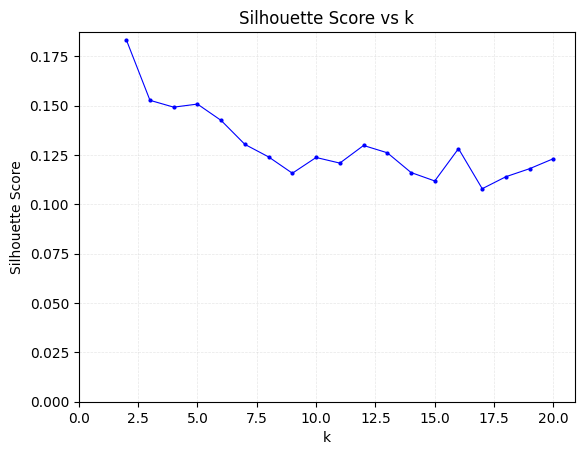

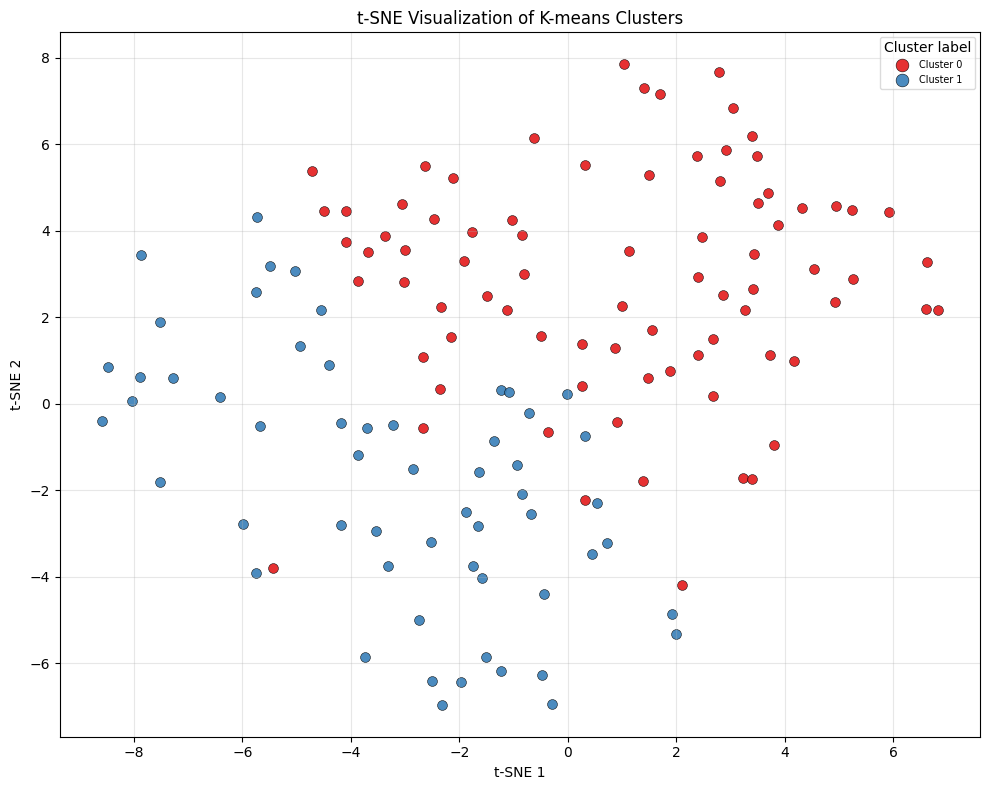

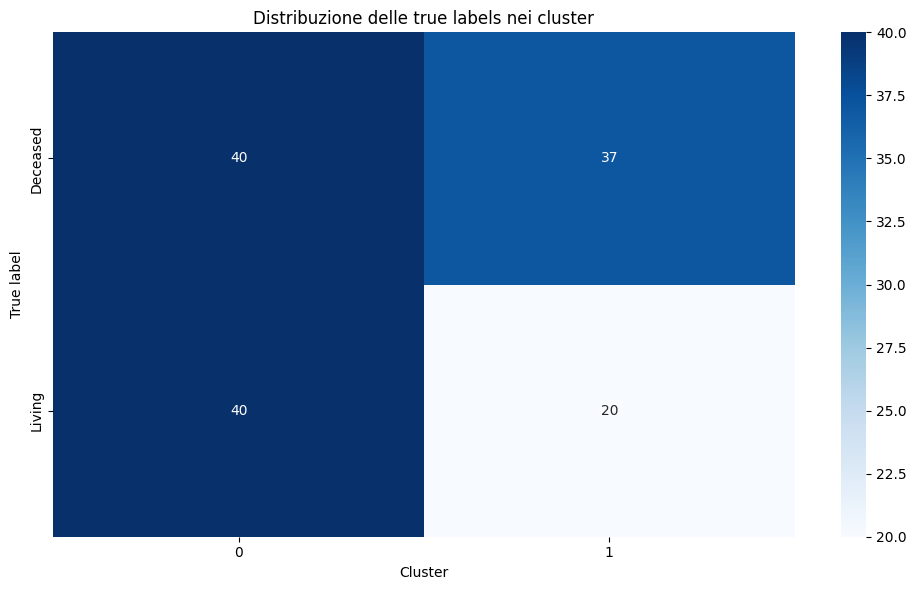

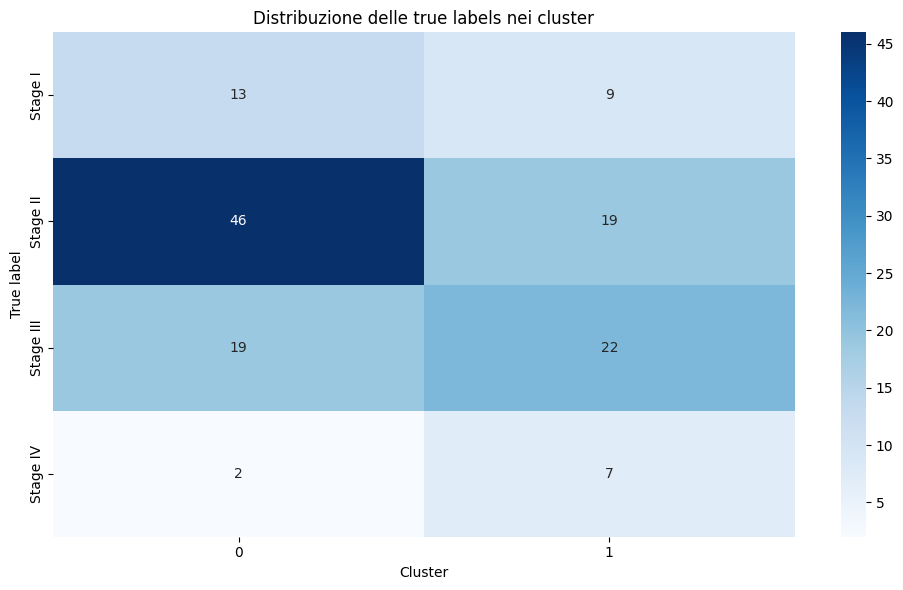

In [ ]:
# GRAFICI K-MEANS

plot_silhouette(range(MIN_CLUSTERS, MAX_CLUSTERS), kmeans_scores['Silhouette'])

plot_tsne(X, labels=best_labels_kmeans, title="t-SNE Visualization of K-means Clusters")    


plot_label_distribution_per_cluster(true_labels_vs, best_labels_kmeans, label_mapping_vs)
plot_label_distribution_per_cluster(true_labels_ts, best_labels_kmeans, label_mapping_ts)

In [7]:
# =======================
# HDBSCAN
# =======================
def run_hdbscan(X):
    print("\nRunning HDBSCAN...")
    
    hdb_model = hdbscan.HDBSCAN(min_cluster_size=2, metric='euclidean')
    best_labels = hdb_model.fit_predict(X)

    # Controllo se HDBSCAN ha trovato più di un cluster
    if len(set(best_labels)) <= 1:
        print("HDBSCAN found only one cluster, unable to compute clustering metrics.")
        sil_score = None
        scores_dict = {'Silhouette': []}
        num_clusters = 0
    else:
        mask = best_labels != -1  # escludi i noise
        sil_score = silhouette_score(X[mask], best_labels[mask])
        scores_dict = {
            'Silhouette': [sil_score],
        }
        num_clusters = len(set(best_labels)) - (1 if -1 in best_labels else 0)

        print(f"Optimal k for HDBSCAN: {num_clusters}")
        print(f"HDBSCAN Silhouette Score={sil_score:.4f}")

    return hdb_model, best_labels, sil_score, scores_dict, num_clusters


hdb_model, best_hdbscan_labels, sil_score_hdbscan, hdbscan_scores, num_clusters_hdbscan = run_hdbscan(X)


Running HDBSCAN...
Optimal k for HDBSCAN: 4
HDBSCAN Silhouette Score=0.2784


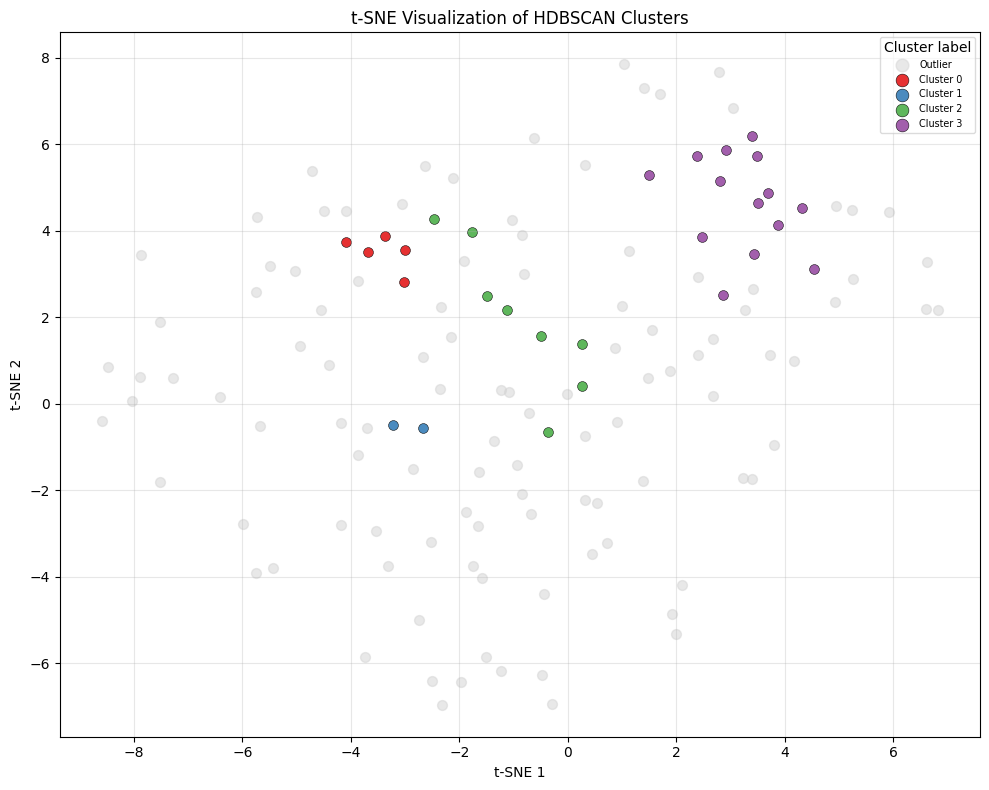

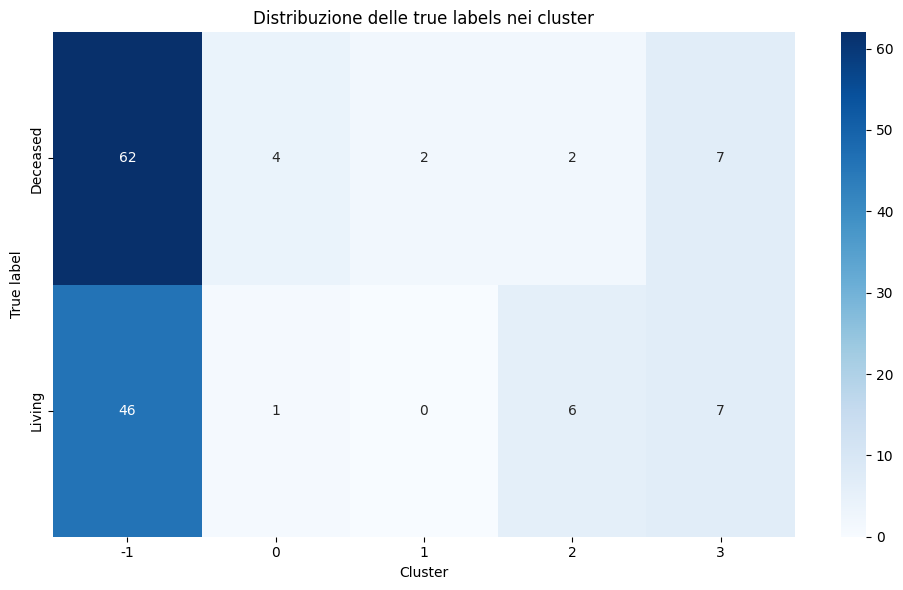

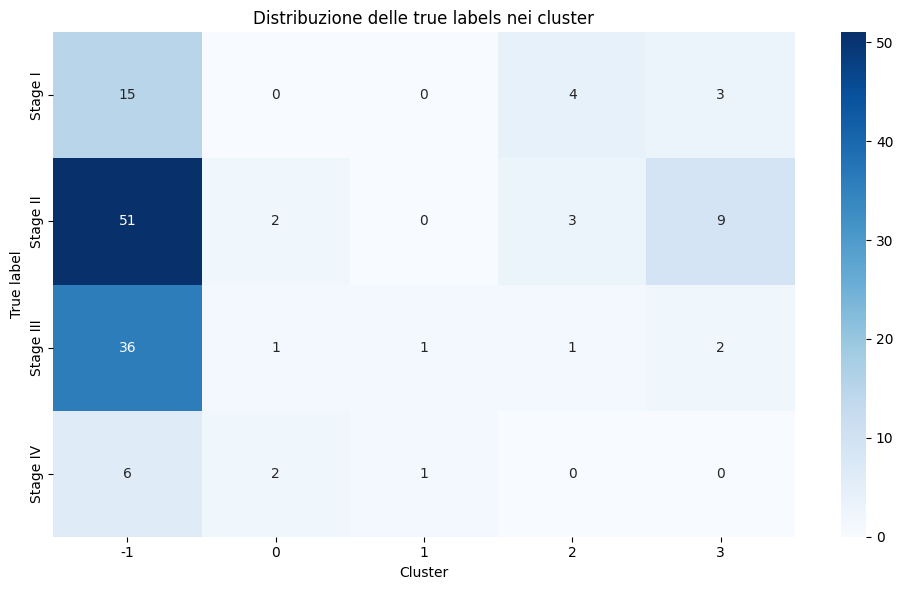

In [ ]:
# GRAFICI HDBSCAN

plot_tsne(X, labels=best_hdbscan_labels, title="t-SNE Visualization of HDBSCAN Clusters")   

plot_label_distribution_per_cluster(true_labels_vs, best_hdbscan_labels, label_mapping_vs)
plot_label_distribution_per_cluster(true_labels_ts, best_hdbscan_labels, label_mapping_ts)


In [9]:
# =======================
# Spectral Clustering
# =======================
def run_spectral_clustering(X, min_clusters=MIN_CLUSTERS, max_clusters=MAX_CLUSTERS, affinity='rbf', random_state=42):
    print("\nRunning Spectral Clustering...")

    sil_scores = []
    best_k = None

    K_range = range(min_clusters, max_clusters)

    # Calcola gamma se affinity='rbf'
    if affinity == 'rbf':
        distances = pairwise_distances(X)
        sigma = np.mean(distances)
        gamma = 1 / (2 * sigma**2)
        print(f"Using gamma={gamma:.4f} for RBF affinity.")
    else:
        gamma = None

    # Loop sui cluster
    for k in K_range:
        if affinity == 'rbf':
            model = SpectralClustering(n_clusters=k, affinity='rbf', gamma=gamma, random_state=random_state)
        else:
            model = SpectralClustering(n_clusters=k, affinity=affinity, random_state=random_state)
        
        labels = model.fit_predict(X)

        sil = silhouette_score(X, labels)

        sil_scores.append(sil)

        print(f"k={k}, Silhouette Score={sil:.4f}")

    # Seleziona il miglior k
    best_idx = np.argmax(sil_scores)
    best_k = K_range[best_idx]
    best_silhouette = sil_scores[best_idx]

    # Fit del modello con il miglior k
    if affinity == 'rbf':
        best_model = SpectralClustering(n_clusters=best_k, affinity='rbf', gamma=gamma, random_state=random_state)
    else:
        best_model = SpectralClustering(n_clusters=best_k, affinity=affinity, random_state=random_state)

    best_labels = best_model.fit_predict(X)

    # Calcola gli indici finali per il modello migliore
    best_silhouette = silhouette_score(X, best_labels)

    print(f"\nOptimal Spectral Clustering: k={best_k}")
    print(f"Silhouette Score={best_silhouette:.4f}")

    scores_dict = {
        'Silhouette': sil_scores,
    }

    return best_model, best_labels, best_silhouette, scores_dict

best_spectral_model, best_spectral_labels, best_spectral_silhouette, spectral_scores = run_spectral_clustering(X, affinity='nearest_neighbors')



Running Spectral Clustering...
k=2, Silhouette Score=0.1198
k=3, Silhouette Score=0.1151
k=4, Silhouette Score=0.1108
k=5, Silhouette Score=0.1060
k=6, Silhouette Score=0.0865
k=7, Silhouette Score=0.0989
k=8, Silhouette Score=0.0733
k=9, Silhouette Score=0.0710
k=10, Silhouette Score=0.0721
k=11, Silhouette Score=0.0924
k=12, Silhouette Score=0.0943
k=13, Silhouette Score=0.0800
k=14, Silhouette Score=0.0902
k=15, Silhouette Score=0.0854
k=16, Silhouette Score=0.0873
k=17, Silhouette Score=0.0826
k=18, Silhouette Score=0.0886
k=19, Silhouette Score=0.0836
k=20, Silhouette Score=0.0821

Optimal Spectral Clustering: k=2
Silhouette Score=0.1198


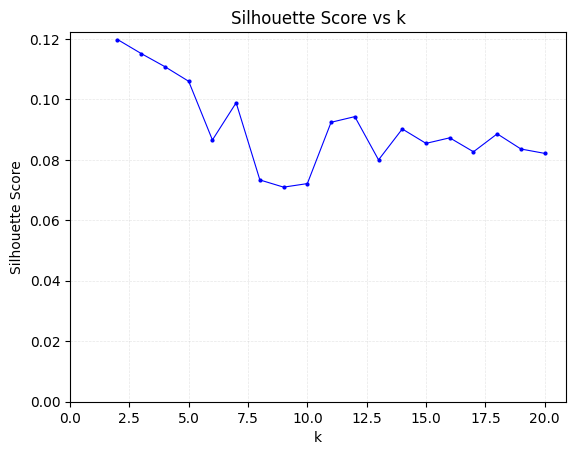

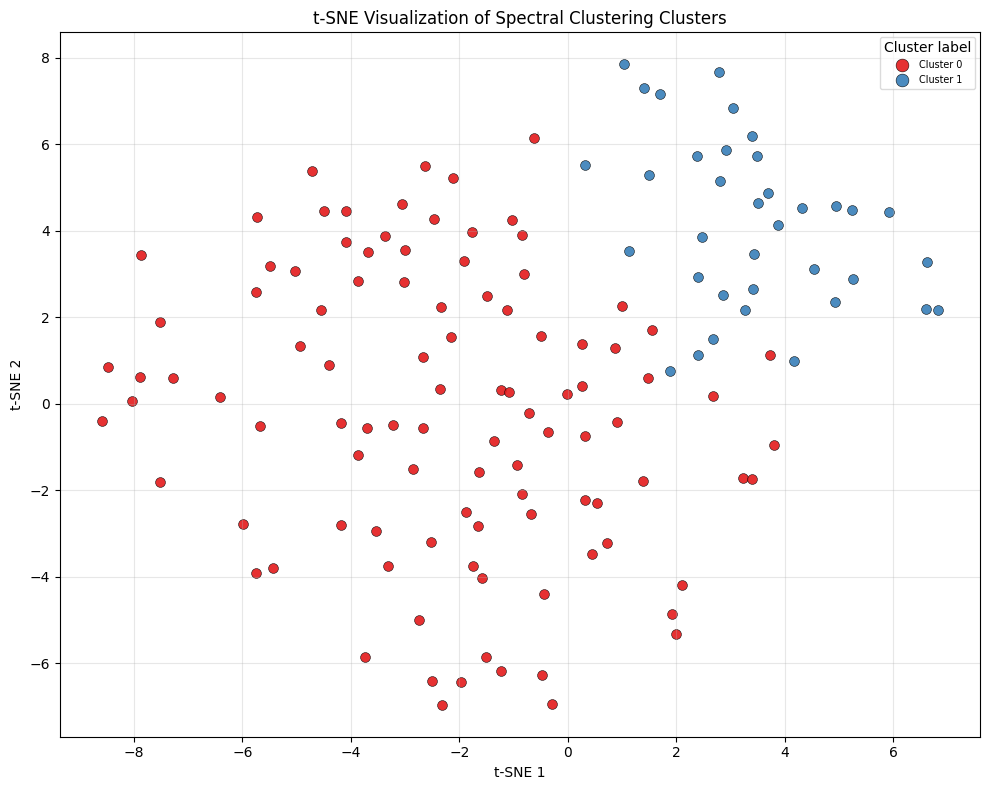

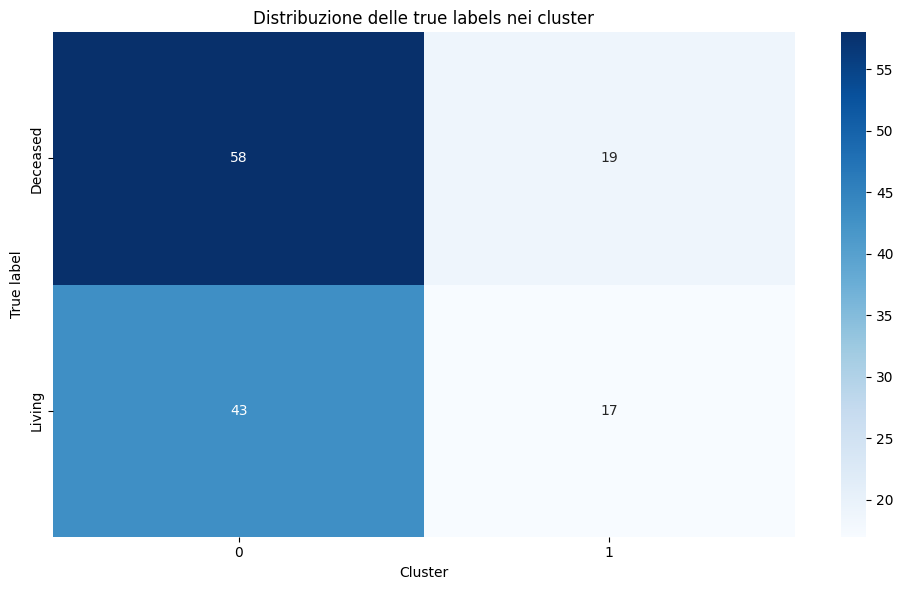

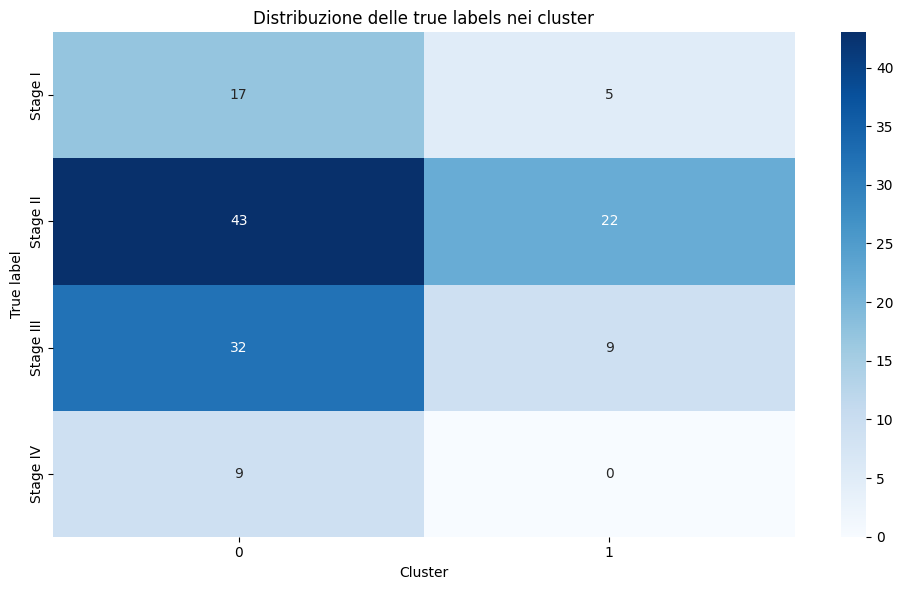

In [ ]:
# GRAFICI SPECTRAL CLUSTERING

plot_silhouette(range(MIN_CLUSTERS, MAX_CLUSTERS), spectral_scores['Silhouette'])

plot_tsne(X, labels=best_spectral_labels, title="t-SNE Visualization of Spectral Clustering Clusters")   


plot_label_distribution_per_cluster(true_labels_vs, best_spectral_labels, label_mapping_vs)
plot_label_distribution_per_cluster(true_labels_ts, best_spectral_labels, label_mapping_ts)

In [11]:
# =======================
# Gaussian Mixture Model
# =======================
def run_gmm_clustering(X, min_clusters=MIN_CLUSTERS, max_clusters=MAX_CLUSTERS, random_state=42):
    print("\nRunning Gaussian Mixture Model (GMM)...")

    lowest_bic = np.inf
    best_model = None
    best_k = None

    # Liste per tutti gli score
    bic_scores = []
    sil_scores = []

    for k in range(min_clusters, max_clusters):
        gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=random_state)
        labels = gmm.fit_predict(X)

        # BIC
        bic = gmm.bic(X)
        bic_scores.append(bic)

        # Silhouette e Calinski-Harabasz
        sil = silhouette_score(X, labels)
        sil_scores.append(sil)

        print(f"k={k}, BIC={bic:.2f}, Silhouette={sil:.4f}")

        # Aggiorna il modello migliore in base al BIC
        if bic < lowest_bic:
            lowest_bic = bic
            best_model = gmm
            best_k = k
            best_silhouette = sil  # silhouette del modello migliore

    best_labels = best_model.predict(X)

    print(f"\nOptimal GMM: k={best_k}, BIC={lowest_bic:.2f}, Silhouette={best_silhouette:.4f}")

    scores_dict = {
        'BIC': bic_scores,
        'Silhouette': sil_scores,
    }

    return best_model, best_labels, best_silhouette, scores_dict

best_gmm_model, best_gmm_labels, best_gmm_silhouette, gmm_scores = run_gmm_clustering(X)


Running Gaussian Mixture Model (GMM)...
k=2, BIC=4253.01, Silhouette=0.2207
k=3, BIC=4547.60, Silhouette=0.1135
k=4, BIC=4758.22, Silhouette=0.1152
k=5, BIC=4930.60, Silhouette=0.1200
k=6, BIC=4819.14, Silhouette=0.1364
k=7, BIC=5047.33, Silhouette=0.1357
k=8, BIC=5211.20, Silhouette=0.1040
k=9, BIC=5605.83, Silhouette=0.1021
k=10, BIC=5743.55, Silhouette=0.1081
k=11, BIC=5524.35, Silhouette=0.0860
k=12, BIC=6009.59, Silhouette=0.0832
k=13, BIC=6068.49, Silhouette=0.0994
k=14, BIC=5901.60, Silhouette=0.0908
k=15, BIC=6222.51, Silhouette=0.0930
k=16, BIC=6440.32, Silhouette=0.1035
k=17, BIC=5939.74, Silhouette=0.1055
k=18, BIC=6197.80, Silhouette=0.1140
k=19, BIC=6683.47, Silhouette=0.1143
k=20, BIC=6050.85, Silhouette=0.1065

Optimal GMM: k=2, BIC=4253.01, Silhouette=0.2207


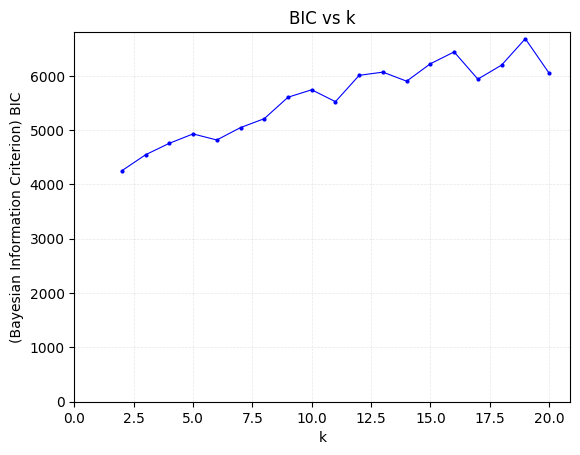

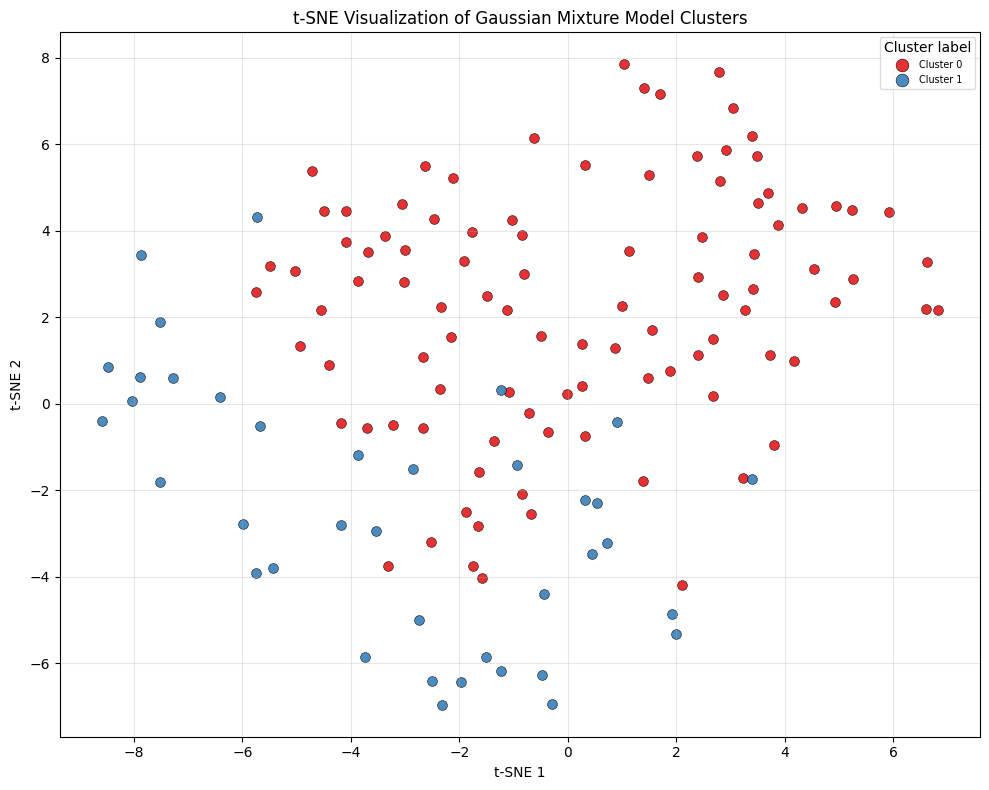

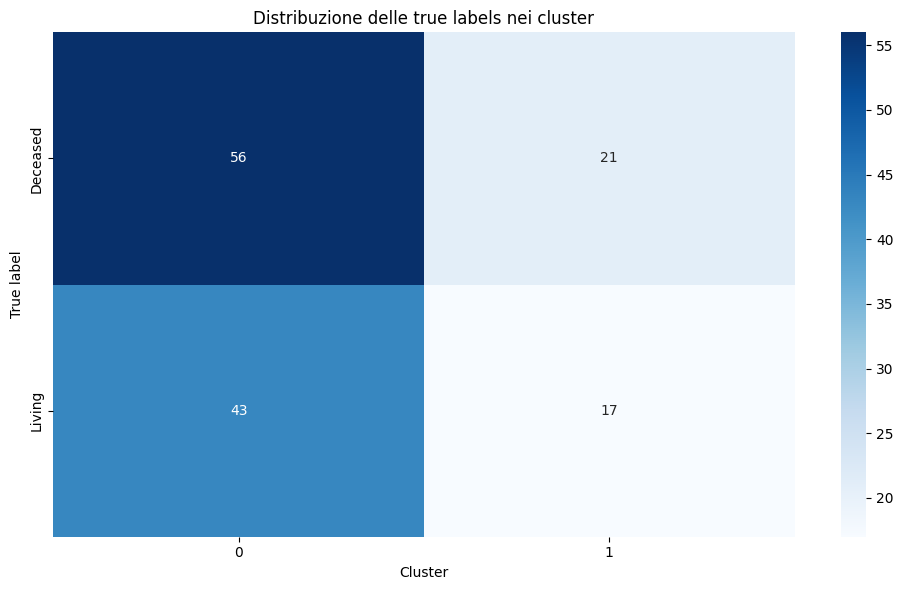

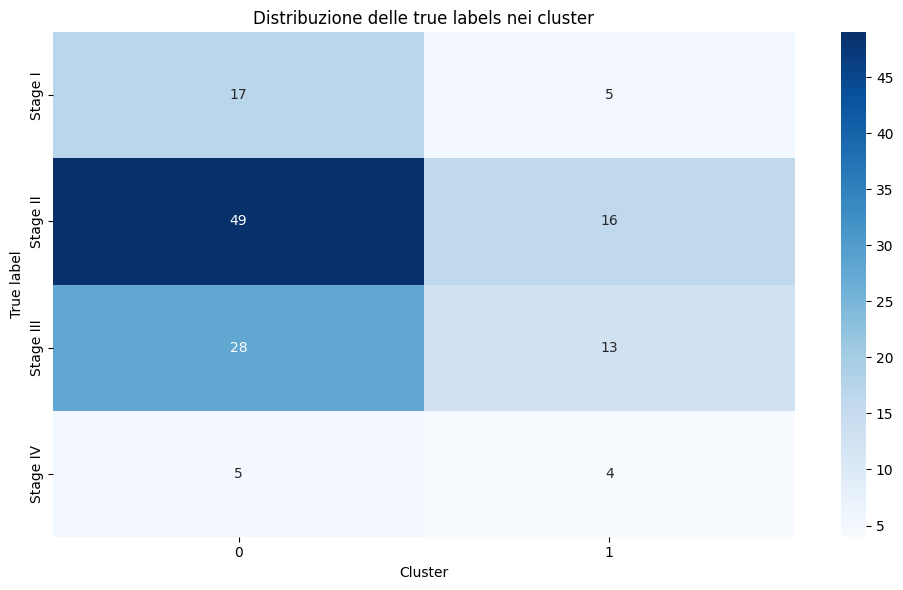

In [ ]:
# GRAFICI Gaussian Mixture Model

#plot_silhouette(K_range_gmm, sil_scores_gmm)
plot_bic(range(MIN_CLUSTERS, MAX_CLUSTERS), gmm_scores['BIC'])

plot_tsne(X, labels=best_gmm_labels, title="t-SNE Visualization of Gaussian Mixture Model Clusters")   


plot_label_distribution_per_cluster(true_labels_vs, best_gmm_labels, label_mapping_vs)
plot_label_distribution_per_cluster(true_labels_ts, best_gmm_labels, label_mapping_ts)


In [13]:
# STAMPA DEL NUMERO DI CLUSTER PER CIASCUNA TECNICA
best_labels = {
    "K-Means": best_labels_kmeans,
    "HDBSCAN": best_hdbscan_labels,
    "Spectral Clustering": best_spectral_labels,
    "GMM": best_gmm_labels
}

def print_cluster_number(labels_dict):
    for method, labels in labels_dict.items():
        if method == "HDBSCAN":
            # Escludi gli outlier (-1)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            print(f"{method}: {n_clusters} clusters")
        else:
            n_clusters = len(set(labels))
            print(f"{method}: {n_clusters} clusters")

print_cluster_number(best_labels)

K-Means: 2 clusters
HDBSCAN: 4 clusters
Spectral Clustering: 2 clusters
GMM: 2 clusters


In [14]:
# SELEZIONE DELLA TECNICA MIGLIORE BASATA SUL SILHOUETTE SCORE


def select_best_clustering_model(best_scores, verbose=True):
    # Trova il modello migliore
    best_model = max(best_scores, key=best_scores.get)
    best_score = best_scores[best_model]

    if verbose:
        print("=== Score di tutti i modelli di clustering ===")
        for model, score in best_scores.items():
            print(f"{model:20s}: {score:.4f}")
        print(f"\nModello di clustering migliore: {best_model} (score = {best_score:.4f})")

    return best_model


best_scores = {
    "K-Means": best_silhouette_kmeans,          
    "HDBSCAN": sil_score_hdbscan,
    "Spectral Clustering": best_spectral_silhouette,  
    "GMM": best_gmm_silhouette                 
}

best_model_name = select_best_clustering_model(best_scores)
print(f"Miglior modello: {best_model_name}")



=== Score di tutti i modelli di clustering ===
K-Means             : 0.1834
HDBSCAN             : 0.2784
Spectral Clustering : 0.1198
GMM                 : 0.2207

Modello di clustering migliore: HDBSCAN (score = 0.2784)
Miglior modello: HDBSCAN


DATA SAVING

In [15]:
# SALAVATAGGIO ETICHETTE DEI CLUSTER
os.makedirs("PDAC_DATA_CLUSTERING", exist_ok=True)


clusters_df = pd.DataFrame(
    best_labels,
    index=clinical_df.index
)

output_path = os.path.join("PDAC_DATA_CLUSTERING", "clusters.csv")

# Salvataggio
clusters_df.to_csv(output_path)